# GMSH Displacement Animation Artifact

This notebook promotes the durable result from `examples/gmsh_animation/`: a GMSH v4.1 mesh carrying time-stepped displacement `$NodeData`, plus a `.geo` companion that merges the static STEP and animated rotor mesh.

The tracked mesh assets remain in `examples/gmsh_animation/` because they are mesh-generation / visualization fixtures. The notebook verifies the artifact structure and writes a durable JSON inspection record.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'gmsh_animation_inspect.py').exists():
    NOTEBOOK_DIR = Path('docs/gmsh_animation').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from gmsh_animation_inspect import inspect_example, write_results_json, format_summary

result = inspect_example()
json_path = write_results_json(result, NOTEBOOK_DIR / 'gmsh_animation_results.json')
print(format_summary(result))
print(f'\nwrote {json_path.relative_to(NOTEBOOK_DIR)}')

mesh_format: 4.1 0 8
nodes: 2430
elements: 1003
NodeData frames: 21
geo merges: stator.step, rotor_animation.msh
final displacement: 0.15 m
checks: v4.1=True, vector=True, time_monotone=True, disp_monotone=True

wrote gmsh_animation_results.json


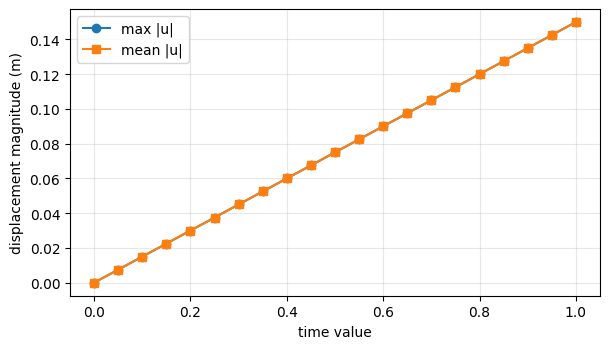

In [2]:
import matplotlib.pyplot as plt

frames = result['msh']['node_data']
times = [row['time_value'] for row in frames]
max_disp = [row['max_norm'] for row in frames]
mean_disp = [row['mean_norm'] for row in frames]

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(times, max_disp, marker='o', label='max |u|')
ax.plot(times, mean_disp, marker='s', label='mean |u|')
ax.set_xlabel('time value')
ax.set_ylabel('displacement magnitude (m)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

The expected result is 21 vector `$NodeData` frames, monotonically increasing from zero to a 0.15 m displacement. The adjacent `gmsh_animation_results.json` stores the checked mesh headers, time values, displacement norms, and file references.